# Визуализация агрегации

In [1]:
from disk_analyzer.research.paths import artifacts_dir
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from disk_analyzer.models import DiskDataset
from disk_analyzer.research.config import DEFAULT_TIMES as TIMES
from disk_analyzer.research.aggregation.predictions_aggregator import PredictionsAggregator
# from disk_analyzer.models.MagiCox import MagiCoxTimeVaryingEstimator
import pickle
import matplotlib.cm as cm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EXP_NUM = 143
RES_FOLDER = str(artifacts_dir(EXP_NUM))
MODELS_FOLDER = os.path.join(RES_FOLDER, "models")
BATCH_SIZE = 1024
DATA = 'Data/Preprocessed_new/30_25_test_preprocessed.csv'
AGG_MODE = 't_dist'
AGG_WEIGHT = 0.1

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:113: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def get_before(estim, wei):
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argu

In [2]:
with open(os.path.join(MODELS_FOLDER, '127_Cox_model.pkl'), 'rb') as f:
    model = pickle.load(f)
# model.__class__ = MagiCoxTimeVaryingEstimator

FileNotFoundError: [Errno 2] No such file or directory: 'Artifacts/Exp_143/models/127_Cox_model.pkl'

In [ ]:
df_test = pd.read_csv(DATA)
print(df_test[df_test['failure'] == 0]['serial_number'].unique())
print(df_test[df_test['failure'] == 1]['serial_number'].unique())

['13H8B2RGS' '5VMAY9R4' '5XW008MX' ... 'ZA189YCJ' 'ZA18BV0X' 'ZCH068F2']
['176FT01GT' '6XW00MWE' '6XW057CW' '87DFWOGHT' '9QM04GKZ' 'JK1101B9GEJEUF'
 'JK1101B9JS452R' 'JK1105B8GDLYGX' 'JK1105B8GG422X' 'JK1131YAJHRBBV'
 'JK11A8B9J2YZTF' 'MJ1311YNG2M29A' 'MJ1311YNG333AA' 'MJ1311YNG36ZVA'
 'MJ1311YNG3K2SA' 'MJ1311YNG6S22A' 'MJ1311YNG733NA' 'MK0301YHGMH23D'
 'MK0311YHGDLWUA' 'MK0311YHGL3H3A' 'MK0313YHGK7VTC' 'PL1311LAG2B1NH'
 'PL1311LAG2E3LH' 'PL1331LAG9E3GH' 'PL1331LAGRDPMH' 'PL1331LAGRUENH'
 'PL1331LAGS04KH' 'PL1331LAGS771H' 'PL1331LAGSE14H' 'PL1331LAHBSRGH'
 'PL1331LAHD2GDH' 'PL1331LAHET8XH' 'PL1331LAHGUAAH' 'PL1331LAHGUZZH'
 'PL2311LAG1KZPC' 'PL2331LAGM8EMJ' 'PL2331LAGMEYVJ' 'PL2331LAGPRW3J'
 'PL2331LAGRWN0J' 'PL2331LAGRWT0J' 'PL2331LAGSTGLJ' 'PL2331LAGUJLMJ'
 'PL2331LAH2ZJEJ' 'PL2331LAH42LTJ' 'PL2331LAH5SXDJ' 'PL2331LAH61XKJ'
 'PL2331LAHAPPXJ' 'PL2331LAHAWPKJ' 'PL2331LAHB4G5J' 'PL2331LAHB94SJ'
 'PL2331LAHBX2HJ' 'PL2331LAHD7YNJ' 'PL2331LAHD9S3J' 'PL2331LAHDHEHJ'
 'S2ZYJ9BF519223' 'S2ZYJ

In [ ]:
TICK_SIZE = 10
def plot_predictions(X_pred, times, ax, shift_pred=True, max_times = np.inf):


    cmap = cm.viridis
    num_lines = len(X_pred)
    colors = [cmap(i / max(num_lines - 1, 1)) for i in range(num_lines)]
    max_time = X_pred['time'].max()

    times_str = set(map(str, times))
    times_cols = [col for col in X_pred.columns if str(col) in times_str]
    for i, (index, row) in enumerate(X_pred.iterrows()):
        
        if not shift_pred:
            cur_times = times[times < max_times]
            ax.plot(
                cur_times,
                row[times_cols].values[:len(cur_times)], 
                color=colors[i],
                label=f'disk = {row.values[0]}, time = {row.values[1]}'
            )
        else:
            cur_times = times - (max_time - row.values[1])  
            ax.plot(
                cur_times[cur_times < max_times],
                row[times_cols].values[:len(cur_times[cur_times < max_times])], #TODO: до len() делать не вполне правильно, потом надо пофиксить
                color=colors[i],
                label=f'disk = {row.values[0]}, time = {row.values[1]}'
            )
    ax.set_title('Predictions')
    ax.grid(True)
    return ax

def plot_disk_predictions(X_pred, serial_number, last_observ_n, amount_observ, times, ax = None, shift_pred=True, X_gt = None, plot_event = True, max_times = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    cur_X_pred = X_pred[X_pred['serial_number'] == serial_number]
    cur_X_pred = cur_X_pred.sort_values(by=['time']).head(last_observ_n).tail(amount_observ)
    ax = plot_predictions(cur_X_pred, times, ax, shift_pred=shift_pred, max_times = max_times)
    if X_gt is not None:
        if plot_event:
            cur_X_gt = X_gt[X_gt['serial_number'] == serial_number] 
            last_time = cur_X_pred.iloc[-1, 1]
            last_duration = cur_X_gt[cur_X_gt['time'] == last_time]['duration'].values[0]
            event = cur_X_gt['failure'].max() == True
            plot_event_line(last_duration, event, ax, TICK_SIZE)
    return ax

def plot_event_line(time, event, ax, fontsize=TICK_SIZE):
    event_color = 'r' if event else 'b'
    ax.axvline(x=time, color=event_color, linestyle='--', linewidth=2)

    # Подописываем момент исхода
    x_fraction = ax.transData.transform((time, 0))[0]
    x_fraction = ax.transAxes.inverted().transform((x_fraction, 0))[0]

    ax.annotate(
        f'{time}',
        xy=(x_fraction, -0.05),       
        xycoords='axes fraction',
        ha='center',
        va='top',
        fontsize=fontsize,
        color=event_color
    )

def get_chain_survival_predictions_for_disk(
    X_pred,
    serial_number,
    times,
    sample_grid,
    pred_agg,
    agg_method,
    agg_weight,
    X_gt=None,
    last_observ_n=None
):
    cur_X_pred = X_pred[X_pred['serial_number'] == serial_number].sort_values(by=['time'])

    if last_observ_n is not None:
        cur_X_pred = cur_X_pred.head(last_observ_n)

    max_chain_len = cur_X_pred.shape[0]
    rows = []
    event = None
    duration = None

    for chain_len in sample_grid:
        if chain_len > max_chain_len:
            continue

        chain = cur_X_pred.tail(chain_len)
        timeshift = chain['time'].max() - chain['time']

        aggregated_pred = pred_agg.predict(chain, times, timeshift=timeshift)
        times_str = set(map(str, times))
        times_cols = [col for col in aggregated_pred.columns if str(col) in times_str]
        survival_curve = aggregated_pred[times_cols].iloc[0].values

        rows.append({
            'chain_len': chain_len,
            'agg_method': agg_method,
            'agg_weight': agg_weight,
            'survival': survival_curve
        })

        if X_gt is not None and event is None and duration is None:
            cur_X_gt = X_gt.loc[cur_X_pred.index]
            event = cur_X_gt['failure'].max()
            duration = cur_X_gt['duration'].min()

    return pd.DataFrame(rows), event, duration


def plot_survival_chains(df, times, ax=None, plot_event=False, event=None, duration=None, max_times = np.inf):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    num_lines = len(df)
    cmap = cm.plasma
    colors = [cmap(i / max(num_lines-1, 1)) for i in range(num_lines)]

    for i, row in enumerate(df.itertuples()):
        ax.plot(times[times < max_times], row.survival[times < max_times], color=colors[i], label=f'len={row.chain_len}', linewidth=2)

    method = df['agg_method'].iloc[0]
    weight = df['agg_weight'].iloc[0]

    if plot_event:
        if event is not None and duration is not None:
            plot_event_line(duration, event, ax=ax)
        else:
            print(f' event = {event} or duration = {duration} is None')

    ax.set_title(f'{method}, weight={weight}', fontsize=14)
    ax.set_xlabel('Time')
    ax.set_ylabel('Survival probability')
    ax.legend(title='Chain length')
    ax.grid(True)
    return ax



In [ ]:
def make_predictions(data:str, pred_agg, times = TIMES):
    df_test = pd.read_csv(data)
    df_test = df_test[df_test['time'] != df_test['max_lifetime']]
    extended_times = pred_agg.get_extended_times(df_test, times = times)
    dl = DataLoader(dataset = DiskDataset('score', [data]),
        batch_size = BATCH_SIZE)
    X_pred, X_gt = model.predict(dl, times=extended_times)
    return X_pred, X_gt

In [ ]:
pred_agg = PredictionsAggregator(mode=AGG_MODE, weight=AGG_WEIGHT)
X_pred, X_gt = make_predictions(DATA, pred_agg, TIMES)
extended_times = pred_agg.get_extended_times(X_pred, times=TIMES)

In [ ]:
def get_agg_for_n_agg(X_pred, times, n_agg, last_observ_n):

    if last_observ_n is not None:
        cur_X_pred = X_pred.groupby('serial_number').head(last_observ_n)

    event = None
    duration = None

    chain = cur_X_pred.groupby('serial_number').tail(n_agg)
    timeshift = chain['time'].groupby('serial_number').transform('max') - chain['time']

    aggregated_pred = pred_agg.predict(chain, times, timeshift=timeshift)

    if X_gt is not None and event is None and duration is None:
        cur_X_gt = X_gt.loc[cur_X_pred.index]
        event = cur_X_gt['failure'].groupby('serial_number').max()
        duration = cur_X_gt['duration'].groupby('serial_number').min()

    return aggregated_pred, event, duration

In [ ]:
X_pred.loc[104957, :720].to_csv('surv.csv', index=False)

In [ ]:
LAST_OBSERV_N = 10
# SERIAL_NUMBER = 'W3006CRJ'
SERIAL_NUMBER = '13H8AB0GS'

df, event, duration = get_agg_for_n_agg(X_pred, TIMES, n_agg=1, last_observ_n=LAST_OBSERV_N)

df

KeyError: 'serial_number'

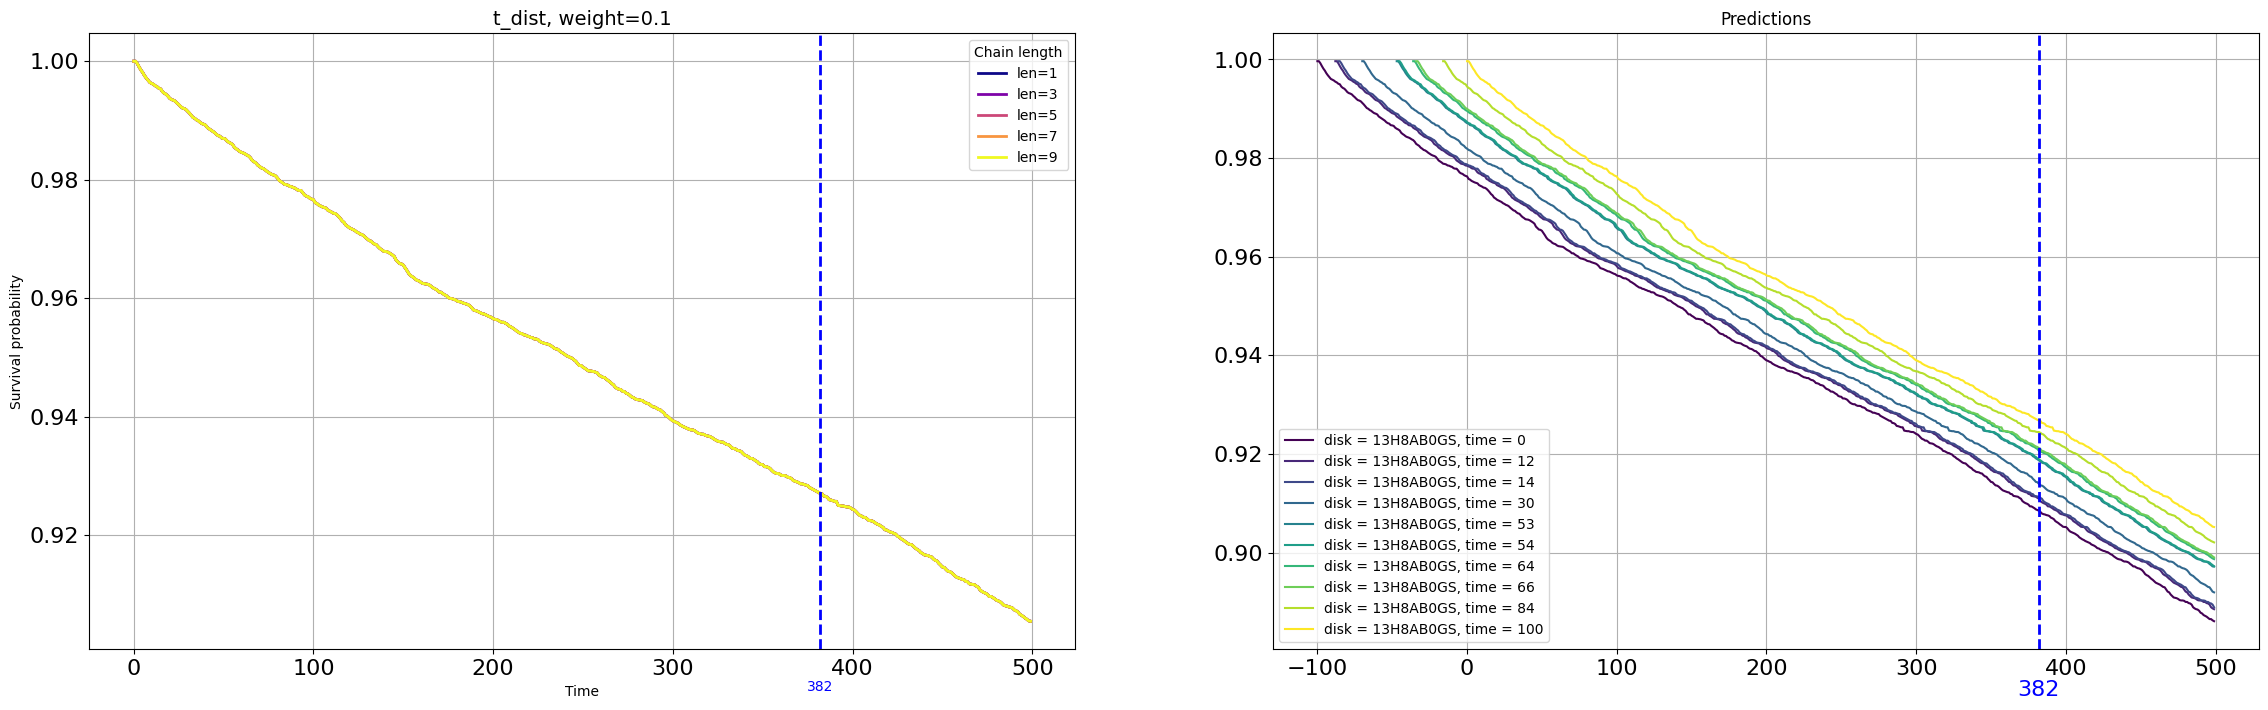

In [ ]:
TICK_SIZE = 16
fig, axes = plt.subplots(1, 2, figsize=(28, 8))
axes[0].tick_params(labelsize=TICK_SIZE)
axes[1].tick_params(labelsize=TICK_SIZE)




plot_disk_predictions(X_pred, SERIAL_NUMBER, LAST_OBSERV_N, 10,  TIMES, ax= axes[1], shift_pred=True, X_gt=X_gt, max_times = 500)
df, event, duration = get_chain_survival_predictions_for_disk(
    X_pred, SERIAL_NUMBER, TIMES, sample_grid=range(1, 10, 2), 
    pred_agg=pred_agg, agg_method=AGG_MODE, agg_weight=AGG_WEIGHT, X_gt = X_gt, last_observ_n=LAST_OBSERV_N
)
plot_survival_chains(df, TIMES, ax= axes[0], plot_event = True, duration = duration, event = event, max_times = 500)
plt.legend()

<Axes: title={'center': 't_dist, weight=0.1'}, xlabel='Time', ylabel='Survival probability'>

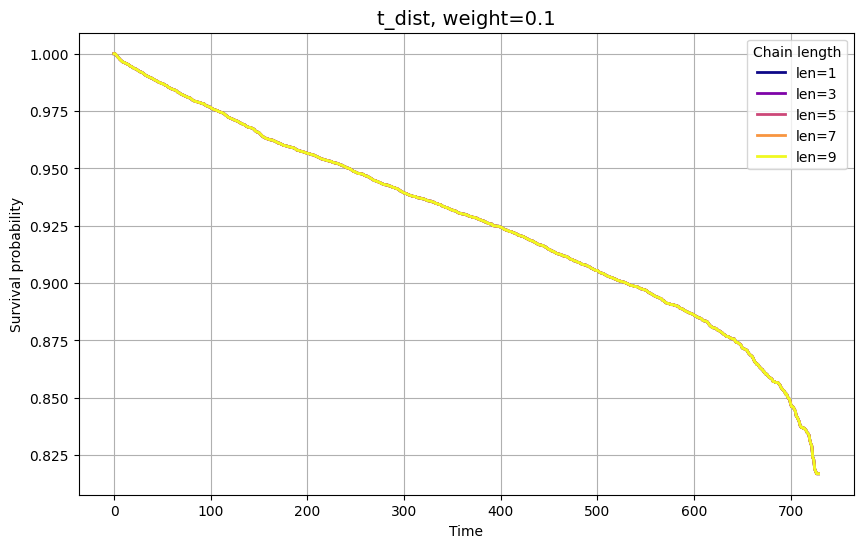

In [ ]:
plot_survival_chains(df, TIMES)